In [1]:
import anndata as ad
import scanpy as sc
import pandas as pd
import numpy as np
import os
from matplotlib import rcParams
import matplotlib.pyplot as plt

/home/cruiz2/miniconda3/envs/cellcharter/lib/python3.10/site-packages/pandas/core/computation/expressions.py:21: UserWarning: Pandas requires version '2.8.4' or newer of 'numexpr' (version '2.7.3' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


In [2]:
rcParams["figure.figsize"] = (5, 5)

In [ ]:
adata=sc.read('/projects/0/einf2548/cruiz/dmg/data/dmg_ascites_prettx_posttx.h5ad')

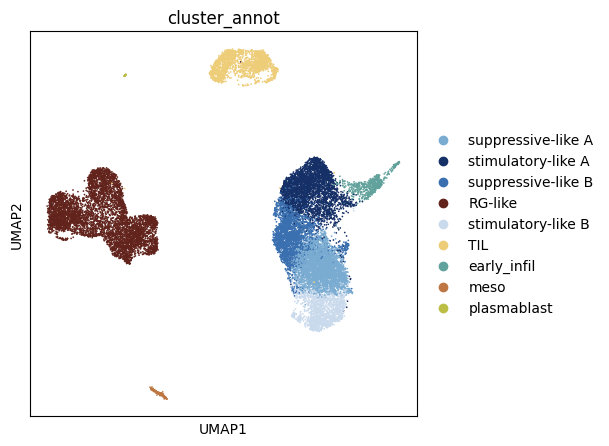

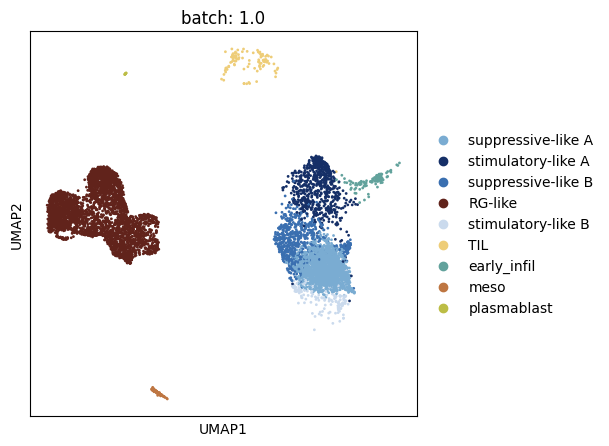

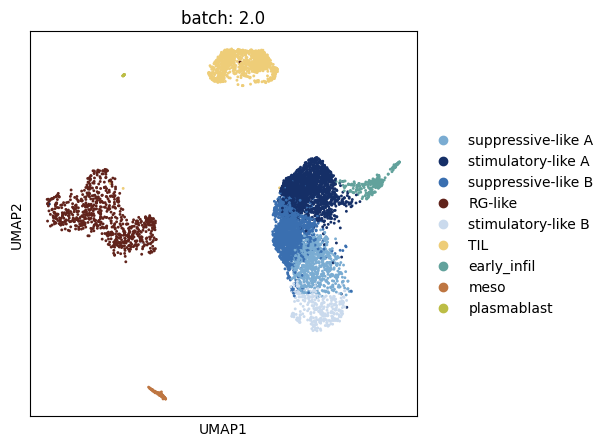

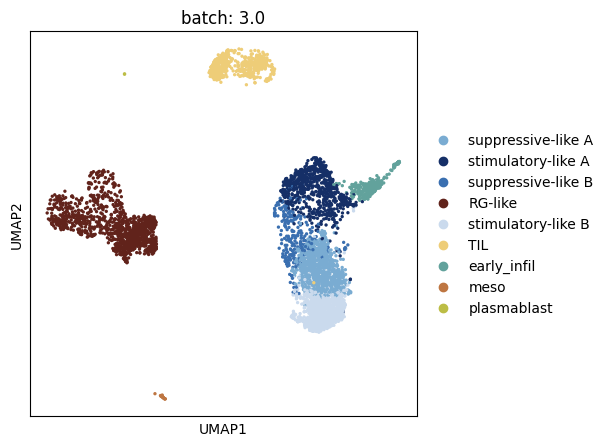

In [18]:
palette = {
    "suppressive-like A": "#7aacd2",
    "stimulatory-like A": "#152f67",
    "suppressive-like B": "#3a6fb0",
    "RG-like": "#61231b",
    "stimulatory-like B": "#cadaed",
    "TIL": "#eecd78",
    "early_infil": "#62a29c",
    "meso": "#be7642",
    "plasmablast": "#bcbd45",
}

cluster_key = "cluster_annot"  
stage_key   = "batch"     

ordered = list(palette.keys())
adata.obs[cluster_key] = adata.obs[cluster_key].astype("category")
adata.obs[cluster_key] = adata.obs[cluster_key].cat.set_categories(ordered)

adata.uns[f"{cluster_key}_colors"] = [palette[c] for c in adata.obs[cluster_key].cat.categories]

sc.pl.umap(adata, color=cluster_key, legend_loc="right margin")


adata.obs[stage_key] = adata.obs[stage_key].astype("category")

stages = list(adata.obs[stage_key].cat.categories)

for st in adata.obs[stage_key].cat.categories:
    sc.pl.umap(
        adata[adata.obs[stage_key] == st],
        color=cluster_key,
        title=f"{stage_key}: {st}",
        legend_loc="right margin",
    )

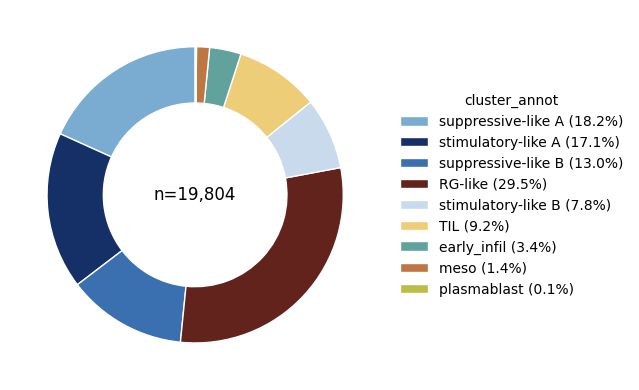

In [19]:
counts = adata.obs[cluster_key].value_counts(dropna=False)

ordered = [c for c in palette.keys() if c in counts.index]
extras  = [c for c in counts.index if c not in palette]
ordered = ordered + extras

counts = counts.loc[ordered]
props = counts / counts.sum()

colors = [palette.get(c, "#bdbdbd") for c in counts.index]

fig, ax = plt.subplots(figsize=(6.5, 6.5))
wedges, _ = ax.pie(
    props.values,
    startangle=90,
    colors=colors,
    labels=None,
    wedgeprops=dict(width=0.38, edgecolor="white", linewidth=1),
)

ax.text(0, 0, f"n={counts.sum():,}", ha="center", va="center", fontsize=12)

legend_labels = [f"{c} ({p*100:.1f}%)" for c, p in zip(counts.index, props.values)]
ax.legend(
    wedges,
    legend_labels,
    title=cluster_key,
    loc="center left",
    bbox_to_anchor=(1.02, 0.5),
    frameon=False,
)

ax.set(aspect="equal")
plt.tight_layout()
plt.show()

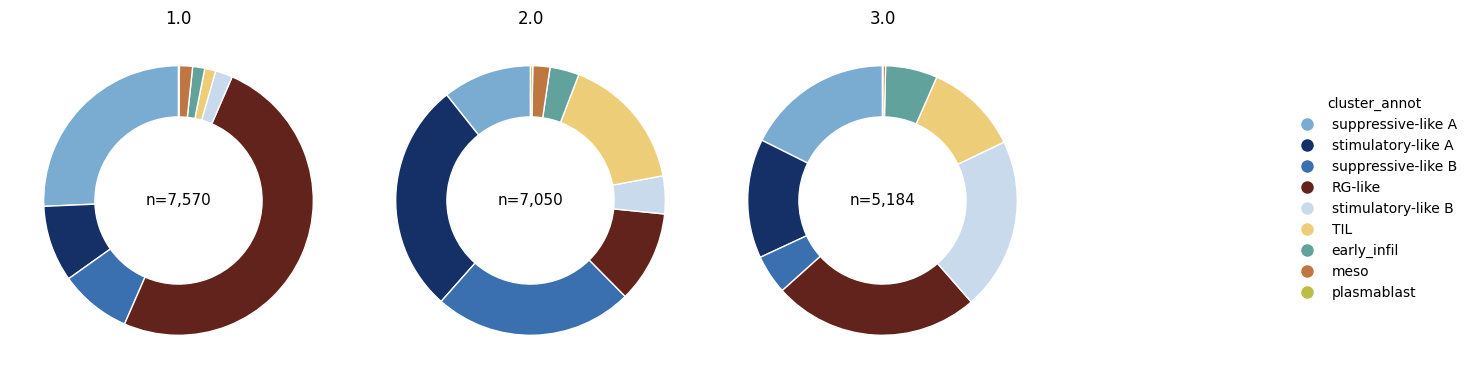

In [20]:
batch_key   = "batch"

all_cats = list(adata.obs[cluster_key].astype("category").cat.categories) \
    if adata.obs[cluster_key].dtype.name == "category" else sorted(adata.obs[cluster_key].unique())

ordered = [c for c in palette if c in all_cats] + [c for c in all_cats if c not in palette]
colors = [palette.get(c, "#bdbdbd") for c in ordered] 

batches = list(adata.obs[batch_key].astype("category").cat.categories) \
    if adata.obs[batch_key].dtype.name == "category" else sorted(adata.obs[batch_key].unique())

n = len(batches)
ncols = 4 if n >= 4 else n
nrows = int(np.ceil(n / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(4.2 * ncols, 4.2 * nrows))
axes = np.array(axes).reshape(-1)

wedge_style = dict(width=0.38, edgecolor="white", linewidth=1)

for i, b in enumerate(batches):
    ax = axes[i]
    sub = adata.obs.loc[adata.obs[batch_key] == b, cluster_key]

    counts = sub.value_counts().reindex(ordered, fill_value=0)
    total = counts.sum()

    if total == 0:
        ax.axis("off")
        continue

    props = counts / total

    wedges, _ = ax.pie(
        props.values,
        startangle=90,
        colors=colors,
        labels=None,
        wedgeprops=wedge_style,
    )
    ax.text(0, 0, f"n={total:,}", ha="center", va="center", fontsize=11)
    ax.set_title(str(b), fontsize=12)
    ax.set(aspect="equal")

for j in range(i + 1, len(axes)):
    axes[j].axis("off")

legend_handles = [
    plt.Line2D([0], [0], marker="o", color="w", markerfacecolor=palette.get(c, "#bdbdbd"),
               markersize=10, label=c)
    for c in ordered
]
fig.legend(
    handles=legend_handles,
    labels=ordered,
    title=cluster_key,
    loc="center left",
    bbox_to_anchor=(1.02, 0.5),
    frameon=False,
)

plt.tight_layout(rect=[0, 0, 0.85, 1]) 
plt.show()

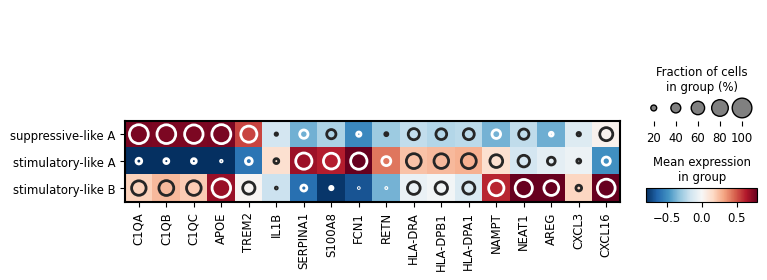

In [35]:
import scanpy as sc

cluster_key = "cluster_annot"
keep_groups = ["suppressive-like A", "stimulatory-like A", "stimulatory-like B"]

genes = [
    "C1QA","C1QB","C1QC","APOE","TREM2","IL1B",
    "SERPINA1","S100A8","FCN1","RETN",
    "HLA-DRA","HLA-DPB1","HLA-DPA1",
    "NAMPT","NEAT1","AREG","CXCL3","CXCL16"
]

adata_sub = adata[adata.obs[cluster_key].isin(keep_groups)].copy()
adata_sub.obs[cluster_key] = adata_sub.obs[cluster_key].astype("category")
adata_sub.obs[cluster_key] = adata_sub.obs[cluster_key].cat.set_categories(keep_groups, ordered=True)

dp = sc.pl.dotplot(
    adata_sub,
    var_names=present,
    groupby=cluster_key,
    cmap="RdBu_r",
    use_raw=False,
    vmin=-0.8, vmax=0.8,
    linewidth=2,
    return_fig=True)
dp.style(color_on="square", cmap="RdBu_r", dot_edge_color=None,
         dot_edge_lw=None, size_exponent=1.5).show()